In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import zipfile

# Path to your archive.zip in Google Drive
zip_path = "/content/drive/MyDrive/archive.zip"  # Update this if it's in a folder

# Folder to extract to
extract_to = "/content/alzheimer_dataset"

# Step 3: Extract the ZIP
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("✅ Dataset extracted to:", extract_to)

✅ Dataset extracted to: /content/alzheimer_dataset


In [ ]:
# Check what folders were extracted
print("Extracted folders:", os.listdir(extract_to))

# Optional: list subfolders if needed
for folder in os.listdir(extract_to):
    print(f"{folder} contains:", os.listdir(os.path.join(extract_to, folder)))

Extracted folders: ['AugmentedAlzheimerDataset', 'OriginalDataset']
AugmentedAlzheimerDataset contains: ['ModerateDemented', 'VeryMildDemented', 'MildDemented', 'NonDemented']
OriginalDataset contains: ['ModerateDemented', 'VeryMildDemented', 'MildDemented', 'NonDemented']


In [ ]:
import os

# Set correct base path (already unzipped)
base_path = "alzheimer_dataset/AugmentedAlzheimerDataset"

# Confirm classes
print("Classes found:", os.listdir(base_path))

Classes found: ['ModerateDemented', 'VeryMildDemented', 'MildDemented', 'NonDemented']


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Parameters
IMG_SIZE = 128
BATCH_SIZE = 32

# Create data generators
datagen = ImageDataGenerator(
    rescale=1./255,           # normalize pixel values
    validation_split=0.2,     # 20% for validation
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

# Load training data (80%)
train_generator = datagen.flow_from_directory(
    base_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# Load validation data (20%)
val_generator = datagen.flow_from_directory(
    base_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 27188 images belonging to 4 classes.
Found 6796 images belonging to 4 classes.


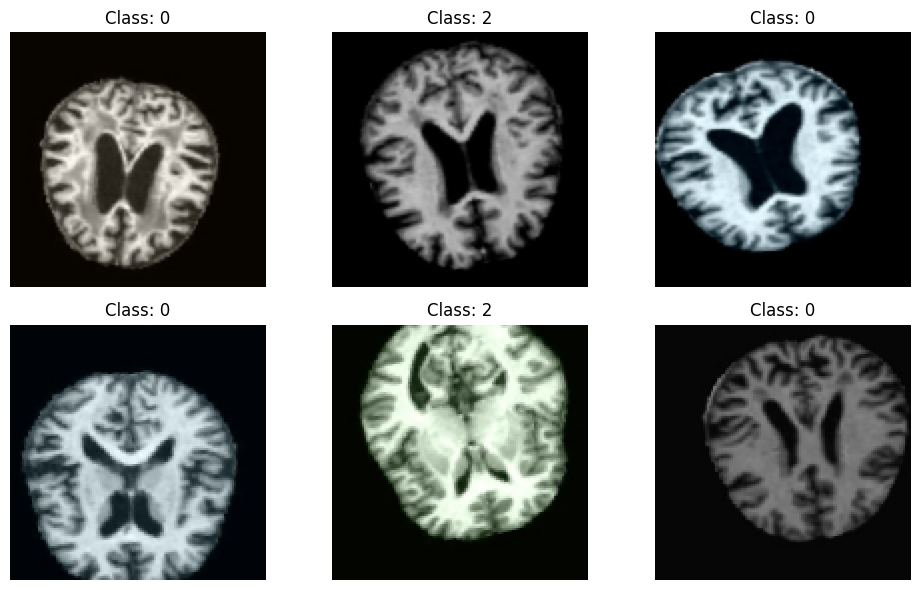

In [ ]:
import matplotlib.pyplot as plt

images, labels = next(train_generator)

plt.figure(figsize=(10, 6))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i])
    plt.title(f"Class: {labels[i].argmax()}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

IMG_SIZE = 128
NUM_CLASSES = 4

model = Sequential()

# Block 1
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

# Block 2
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

# Block 3
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

# Block 4
model.add(Conv2D(256, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

# Classifier
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(NUM_CLASSES, activation='softmax'))

# Summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,750,916 (10.49 MB)

 Trainable params: 2,749,956 (10.49 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ModelCheckpoint("best_cnn_model.h5", save_best_only=True)
]

In [ ]:
EPOCHS = 25

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks
)

Epoch 1/25
850/850 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.3099 - loss: 1.8301

850/850 ━━━━━━━━━━━━━━━━━━━━ 168s 190ms/step - accuracy: 0.3099 - loss: 1.8297 - val_accuracy: 0.2997 - val_loss: 1.3507
Epoch 2/25
850/850 ━━━━━━━━━━━━━━━━━━━━ 189s 180ms/step - accuracy: 0.3774 - loss: 1.2734 - val_accuracy: 0.2624 - val_loss: 1.4138
Epoch 3/25
850/850 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.3988 - loss: 1.2096

850/850 ━━━━━━━━━━━━━━━━━━━━ 165s 194ms/step - accuracy: 0.3988 - loss: 1.2096 - val_accuracy: 0.5168 - val_loss: 1.0646
Epoch 4/25
850/850 ━━━━━━━━━━━━━━━━━━━━ 153s 179ms/step - accuracy: 0.4715 - loss: 1.1160 - val_accuracy: 0.2563 - val_loss: 1.3596
Epoch 5/25
850/850 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.5337 - loss: 1.0274

850/850 ━━━━━━━━━━━━━━━━━━━━ 153s 180ms/step - accuracy: 0.5337 - loss: 1.0274 - val_accuracy: 0.5806 - val_loss: 0.9706
Epoch 6/25
850/850 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.5710 - loss: 0.9559

850/850 ━━━━━━━━━━━━━━━━━━━━ 201s 179ms/step - accuracy: 0.5710 - loss: 0.9559 - val_accuracy: 0.6161 - val_loss: 0.8635
Epoch 7/25
850/850 ━━━━━━━━━━━━━━━━━━━━ 165s 195ms/step - accuracy: 0.5955 - loss: 0.8914 - val_accuracy: 0.5784 - val_loss: 0.9240
Epoch 8/25
850/850 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.6125 - loss: 0.8431

...

850/850 ━━━━━━━━━━━━━━━━━━━━ 154s 181ms/step - accuracy: 0.7449 - loss: 0.5554 - val_accuracy: 0.7625 - val_loss: 0.5415
Epoch 17/25
850/850 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.7666 - loss: 0.5255

850/850 ━━━━━━━━━━━━━━━━━━━━ 155s 182ms/step - accuracy: 0.7666 - loss: 0.5255 - val_accuracy: 0.7815 - val_loss: 0.4653
Epoch 18/25
850/850 ━━━━━━━━━━━━━━━━━━━━ 153s 180ms/step - accuracy: 0.7780 - loss: 0.4989 - val_accuracy: 0.7494 - val_loss: 0.5376
Epoch 19/25
850/850 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.7841 - loss: 0.4960

850/850 ━━━━━━━━━━━━━━━━━━━━ 154s 181ms/step - accuracy: 0.7841 - loss: 0.4960 - val_accuracy: 0.8136 - val_loss: 0.4118
Epoch 20/25
850/850 ━━━━━━━━━━━━━━━━━━━━ 166s 195ms/step - accuracy: 0.7928 - loss: 0.4730 - val_accuracy: 0.7840 - val_loss: 0.4820
Epoch 21/25
850/850 ━━━━━━━━━━━━━━━━━━━━ 188s 178ms/step - accuracy: 0.8063 - loss: 0.4472 - val_accuracy: 0.8100 - val_loss: 0.4755
Epoch 22/25
850/850 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.8072 - loss: 0.4401

850/850 ━━━━━━━━━━━━━━━━━━━━ 155s 182ms/step - accuracy: 0.8072 - loss: 0.4401 - val_accuracy: 0.8280 - val_loss: 0.3964
Epoch 23/25
850/850 ━━━━━━━━━━━━━━━━━━━━ 152s 178ms/step - accuracy: 0.8264 - loss: 0.4070 - val_accuracy: 0.8243 - val_loss: 0.4030
Epoch 24/25
850/850 ━━━━━━━━━━━━━━━━━━━━ 166s 195ms/step - accuracy: 0.8310 - loss: 0.3939 - val_accuracy: 0.8208 - val_loss: 0.4728
Epoch 25/25
850/850 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.8388 - loss: 0.3895

850/850 ━━━━━━━━━━━━━━━━━━━━ 154s 181ms/step - accuracy: 0.8388 - loss: 0.3895 - val_accuracy: 0.8561 - val_loss: 0.3395


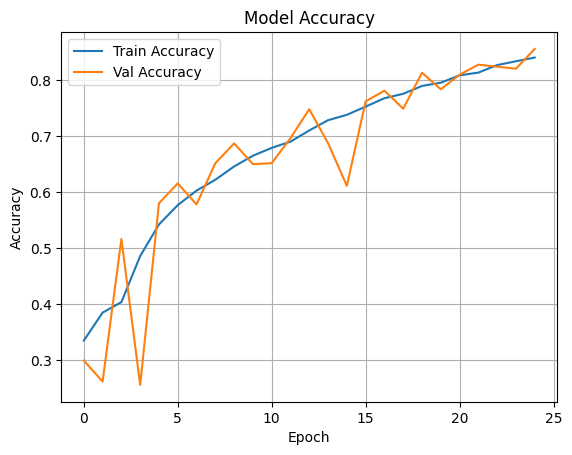

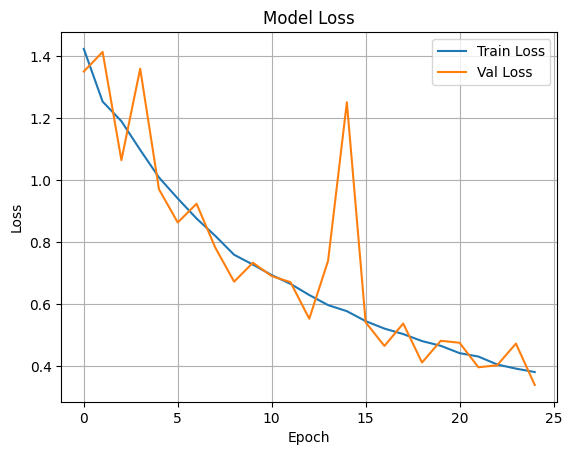

In [ ]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss plot
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
val_loss, val_acc = model.evaluate(val_generator)
print(f"\n✅ Final Validation Accuracy: {val_acc * 100:.2f}%")

213/213 ━━━━━━━━━━━━━━━━━━━━ 31s 144ms/step - accuracy: 0.9266 - loss: 0.1961

✅ Final Validation Accuracy: 85.87%


In [ ]:
import numpy as np

# Predict class probabilities
Y_pred = model.predict(val_generator)

# Convert probabilities to class indices
y_pred = np.argmax(Y_pred, axis=1)

# True class indices from the generator
y_true = val_generator.classes

# Class labels mapping (dict)
class_names = list(val_generator.class_indices.keys())

print("Class labels:", class_names)


213/213 ━━━━━━━━━━━━━━━━━━━━ 31s 140ms/step
Class labels: ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']


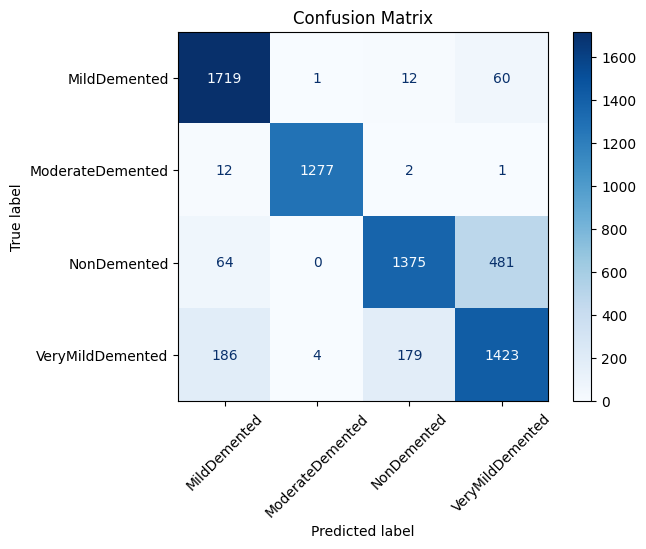

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()


In [ ]:
from sklearn.metrics import classification_report

report = classification_report(y_true, y_pred, target_names=class_names)
print("🔍 Classification Report:\n")
print(report)


🔍 Classification Report:

                  precision    recall  f1-score   support

    MildDemented       0.87      0.96      0.91      1792
ModerateDemented       1.00      0.99      0.99      1292
     NonDemented       0.88      0.72      0.79      1920
VeryMildDemented       0.72      0.79      0.76      1792

        accuracy                           0.85      6796
       macro avg       0.87      0.86      0.86      6796
    weighted avg       0.86      0.85      0.85      6796



Saving download.jpg to download.jpg


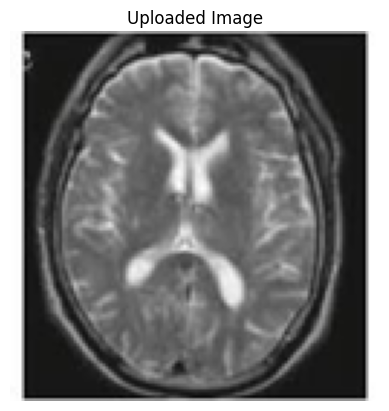

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
✅ Predicted Class: VeryMildDemented
🔢 Confidence: 100.00%


In [ ]:
from google.colab import files
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# STEP 1: Upload the image
uploaded = files.upload()  # Select an image (JPG or PNG)

# STEP 2: Get the file name
filename = next(iter(uploaded))  # Automatically get uploaded filename

# STEP 3: Load and preprocess the image
img = Image.open(filename).convert("RGB")
img = img.resize((128, 128))  # Match your model input size

# Optional: Display the image
plt.imshow(img)
plt.title("Uploaded Image")
plt.axis("off")
plt.show()

# Preprocess for model
img_array = np.array(img) / 255.0  # Normalize
img_array = np.expand_dims(img_array, axis=0)  # Shape: (1, 128, 128, 3)

# STEP 4: Predict using your trained model
pred = model.predict(img_array)
predicted_class = np.argmax(pred)
confidence = np.max(pred) * 100

# STEP 5: Map index to class label
class_labels = list(train_generator.class_indices.keys())
predicted_label = class_labels[predicted_class]

# STEP 6: Show prediction
print(f"✅ Predicted Class: {predicted_label}")
print(f"🔢 Confidence: {confidence:.2f}%")